In [69]:
'''
Curso : Analisis de Datos con Python
Sesion : 3
Tema  : Desarrollo de modelos
Fecha : 10/01/2026
Actualizacion : 12/09/2026
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Libreria Seabord 
https://seaborn.pydata.org/


In [70]:
file_path = 'dataset/autos_sin_nan.csv'
df = pd.read_csv(file_path)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [71]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object

In [72]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    1
diesel               0
gas                  0
dtype: int64

In [73]:
df.dropna(axis=0, inplace=True)

In [74]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    0
diesel               0
gas                  0
dtype: int64

## 1.- Regresión Simple

#### Ecuación de regresión simple 

- $ y = b_0  + b_1x + error $

- $ \hat{y} = b_0  + b_1x$

##### Error

- $ error = y - \hat{y} $

##### Concluimos
- $ y = \hat{y} + error $

### Seleccionando variables, hallando matriz de correlación y graficando histogramas

In [90]:
v_num = df.select_dtypes(["float64", "int64"])
v_num = list(v_num.columns)
v_num

['symboling',
 'normalized-losses',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-size',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price',
 'city-L/100km',
 'diesel',
 'gas']

In [96]:
df[v_num].corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.453423,-0.533112,-0.359883,-0.242821,-0.539407,-0.226121,-0.055329,-0.142125,-0.013520,-0.180275,0.090778,0.229436,0.004688,0.073359,-0.076420,0.021612,-0.192544,0.192544
normalized-losses,0.453423,1.000000,-0.046971,0.027234,0.090056,-0.362499,0.107034,0.147862,-0.030152,0.056054,-0.112288,0.226654,0.215903,-0.208695,-0.166772,0.138183,0.223308,-0.096487,0.096487
wheel-base,-0.533112,-0.046971,1.000000,0.876945,0.821427,0.607417,0.790205,0.592517,0.493941,0.163725,0.248383,0.381984,-0.351925,-0.496565,-0.566948,0.591956,0.517050,0.305889,-0.305889
length,-0.359883,0.027234,0.876945,1.000000,0.857249,0.522367,0.882091,0.698626,0.608496,0.136850,0.156926,0.583073,-0.280397,-0.686142,-0.715124,0.689466,0.690579,0.212484,-0.212484
width,-0.242821,0.090056,0.821427,0.857249,1.000000,0.351127,0.862835,0.739543,0.543859,0.210495,0.188331,0.604099,-0.252116,-0.639692,-0.684550,0.744176,0.685663,0.251112,-0.251112
height,-0.539407,-0.362499,0.607417,0.522367,0.351127,1.000000,0.354085,0.100518,0.199490,-0.084755,0.269773,-0.031489,-0.270020,-0.128523,-0.181670,0.182407,0.111120,0.279063,-0.279063
curb-weight,-0.226121,0.107034,0.790205,0.882091,0.862835,0.354085,1.000000,0.858968,0.646918,0.193575,0.153952,0.750749,-0.281231,-0.766146,-0.808146,0.828483,0.809512,0.228445,-0.228445
engine-size,-0.055329,0.147862,0.592517,0.698626,0.739543,0.100518,0.858968,1.000000,0.601384,0.265626,0.017246,0.825377,-0.227577,-0.712693,-0.734062,0.889265,0.814696,0.076032,-0.076032
bore,-0.142125,-0.030152,0.493941,0.608496,0.543859,0.199490,0.646918,0.601384,1.000000,-0.049606,-0.000044,0.579114,-0.276668,-0.591597,-0.598455,0.544375,0.574286,0.055927,-0.055927
stroke,-0.013520,0.056054,0.163725,0.136850,0.210495,-0.084755,0.193575,0.265626,-0.049606,1.000000,0.191776,0.139409,-0.067852,-0.050971,-0.052345,0.107893,0.065893,0.240193,-0.240193


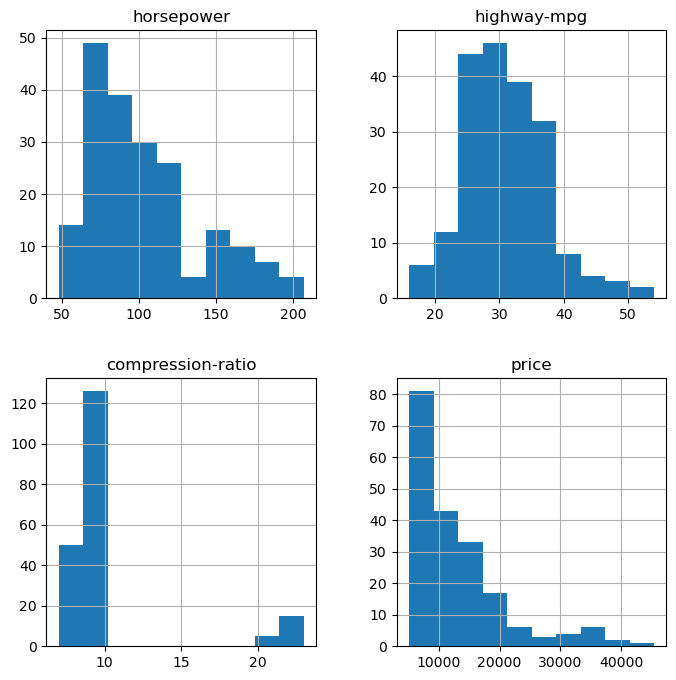

In [97]:
df[['horsepower',
    'highway-mpg',
    'compression-ratio',
    'price']].hist(layout=(2,2),
                     sharex=False,sharey=False,figsize=(8,8))
plt.show()

Aplicando regresión simple, mostrando los coeficientes y escribiendo la ecuación


### Scikit-Learn

https://scikit-learn.org/stable/

In [101]:
# Regresion Lineal usando sklearn
from sklearn.linear_model import LinearRegression

# lm es el modelo de regresion lineal
lm = LinearRegression()

x = df[['horsepower']]
y = df['price']


In [102]:
# ajustar el modelo ( calcular b0 y b1 )
lm.fit(x,y)

# coeficiente
b0 = lm.intercept_
b1 = lm.coef_
print("b0:", b0)
print("b1:", b1)

b0: -4879.505989269364
b1: [175.40561198]


$$ \hat{y} = -4879.51 + 175.406x $$

Graficando la ecuación y los residuales

### Función regplot : Gráfico de regresión lineal

https://seaborn.pydata.org/generated/seaborn.regplot.html#seaborn.regplot

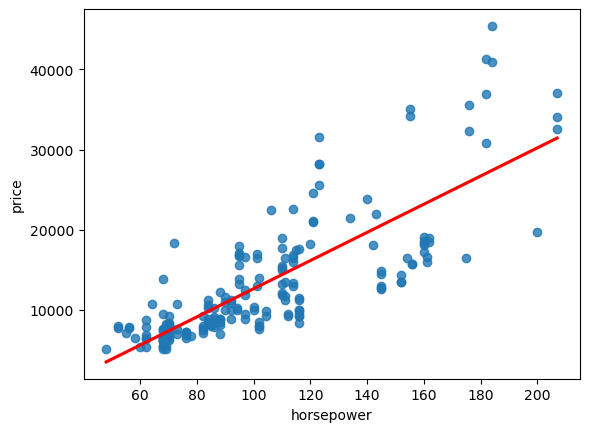

In [108]:

# ci : confidence interval
sns.regplot(x='horsepower', y='price', data=df ,  fit_reg=True, ci=0.98, line_kws={'color':'red'})
plt.show()

### Función residplot : Gráfico de residuales

https://seaborn.pydata.org/generated/seaborn.residplot.html#seaborn-residplot

In [ ]:
sns.residplot(x='horsepower', y='price', data=df)
plt.show()

### Tarea 
Encontrar el modelo de regresióm simple para las siguiente variables:
- highway-mpg con el precio
- compression-ratio con el precio


In [ ]:
# Gráfico de regresión
sns.regplot(x='highway-mpg', y='price', data=df, fit_reg=True)
plt.title("Regresión: highway-mpgo vs price")
plt.ylim(0,)
plt.show()


In [ ]:
# Gráfico de residuales
sns.residplot(x='highway-mpg', y='price', data=df)
plt.title("Residuales: highway-mpg vs price")
plt.show()

In [ ]:
def modelo(x,y,lm):
    lm.fit(x,y)
    # coeficiente
    b0 = lm.intercept_
    b1 = lm.coef_
    print("b0:", b0)
    print("b1:", b1)

def graf_regre_lineal(x,y):
    sns.regplot(x = x,
                y = y,
                data=df ,
                fit_reg=True,
                ci = 95)
    plt.show()

def graf_residuales(x,y,df):
    sns.residplot(x= x, y= y, data=df)
    plt.ylabel('Residuales')
    plt.grid()
    plt.show()



###########################################
# Regresion Lineal usando sklearn
from sklearn.linear_model import LinearRegression

# lm es el modelo de regresion lineal
lm = LinearRegression()

x = df[['highway-mpg']]
y = df['price']

modelo(x,y,lm)


x = 'highway-mpg'
y = 'price'

graf_regre_lineal(x,y)
graf_residuales(x,y,df)

In [ ]:
plt.title("Regresión: compression-ratio vs price")

sns.regplot(x='compression-ratio', y='price', data=df, fit_reg=True)
plt.ylim(0,)
plt.show()

In [ ]:
# Gráfico de residuales
sns.residplot(x='compression-ratio', y='price', data=df)
plt.show()

## 2.- Regresión múltiple

#### Ecuación de regresión múltiple

$ y = b_0 + b_1x_1 + b_2x_2 +...+ b_nx_n + error $

$ \hat{y} = b_0 + b_1x_1 + b_2x_2 +...+ b_nx_n $

#### Error
$ y - \hat{y} = error $

#### Concluimos
$ y = \hat{y} + error $


In [ ]:
# Seleccionando variables predictoras
# Las variables predictoras se seleccionan en base a la correlacion 
# con la variable 'price'

cdf = df[['horsepower', 'highway-mpg', 'compression-ratio', 'price']]
cdf.head()

In [ ]:
# Regresion Lineal usando sklearn
from sklearn.linear_model import LinearRegression

# lm es el modelo de regresion lineal
lm = LinearRegression()

X = cdf[['horsepower', 'highway-mpg', 'compression-ratio']]
Y = cdf[['price']]


In [ ]:
# Ajustar el modelo ( calcular b0 , b1, b2, y b3 )
lm.fit(X,Y)

# coeficiente
b0 = lm.intercept_
b = lm.coef_
print("b0:", b0)
print("b:", b)

$$  \hat{y} =  569.11 +  148.56x_1 -272.35x_2  +562.37x_3 $$

### Graficando los residuales

- $ error = y - \hat{y} $

In [ ]:

# Calculo Yhat
Yhat = lm.predict(X)

# Calculo error
error = Y.values - Yhat


In [ ]:
plt.scatter(Yhat, error)
plt.xlabel("Yhat")
plt.ylabel("Error")
plt.show()

In [ ]:
# Residuales vs valores predichos (el más importante)
plt.figure(figsize=(8, 5))
plt.scatter(Yhat, error, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuales')
plt.title('Residuales vs Predichos')
plt.show()

In [ ]:

## Ejercicio : Realizar un modelo de regresion múltiple con las variables siguientes
# 'curb-weight', 'engine-size', 'highway-mpg' y 'price'




In [ ]:
cdf = df[['curb-weight',
         'engine-size',
         'highway-mpg',
         'price']]
cdf.head()

# lm es el modelo de regresion lineal
lm = LinearRegression()

X = cdf[['curb-weight',
         'engine-size',
         'highway-mpg']]
Y = cdf[['price']]

# Ajustar el modelo ( calcular b0 y b )
lm.fit(X,Y)

# coeficiente
b0 = lm.intercept_
b = lm.coef_
print("b0:", b0)
print("b:", b)

# Calculo Yhat
Yhat = lm.predict(X)

# Calculo error
error = Y.values - Yhat

# Residuales vs valores predichos (el más importante)
plt.figure(figsize=(8, 5))
plt.scatter(Yhat, error, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuales')
plt.title('Residuales vs Predichos')
plt.show()

$$  \hat{y} =  -11876 +  3.45x_1 +136.51x_2  - 37.39x_3 $$

- **curb-weight** : por cada unidad de peso y manteniendo constante la cilindrada del motor y el consumo por millas en autopista , el precio del auto subo 3.45$.
- **engine-size** : por cada incremento de una cilindrada del motor y manteniendo constante el peso y consumo por millas del auto, el precio se incrementa n 136.51$
- **highway-pmg** : por cada milla por galon extra y manteniendo constante el peso y cilindrada del motor constante el precio se reduce en 37.39$


## 3.- Regresión Polinómica

- Cuadrática (segundo orden)
$$ \hat{y} = b_0 + b_1x + b_2x^2 $$

- Cúbica (tercer orden)
$$ \hat{y} = b_0 + b_1x + b_2x^2 + b_3x^3 $$

- Superior (n-ésimo orden)
$$ \hat{y} = b_0 + b_1x + b_2x^2 + b_3x^3 +...+ b_nx^n $$

In [ ]:
# Regresion polinomica de grado 2

X = df['highway-mpg']
Y = df['price']
grade = 2

# Ajuste polinomico
f = np.polyfit(X, Y, grade)

print(f)

In [ ]:
p = np.poly1d(f)
print(p)

$$ \hat{y} = 86265.83 -3870.87x + 46.45x^2 $$

In [ ]:
def plot_poly(model, independent_variable, dependent_variable, name, title):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)
    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title(title)
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(name)
    plt.ylabel('price')
    plt.show()

In [ ]:
plot_poly(p, X, Y, 'highway-mpg','Gráfica de regresión polinómica de grado 2')

In [ ]:
# Regresion polinomica de grado 3

X = df['highway-mpg']
Y = df['price']
grade = 3

# Ajuste polinomico
f = np.polyfit(X, Y, grade)

print(f)

In [ ]:
p = np.poly1d(f)
print(p)

In [ ]:
plot_poly(p, X, Y, 'highway-mpg','Gráfica de regresión polinómica de grado 3')

In [ ]:
# Regresion polinomica de grado 11

X = df['highway-mpg']
Y = df['price']
grade = 11

# Ajuste polinomico
f = np.polyfit(X, Y, grade)

print(f)

In [ ]:
p = np.poly1d(f)
print(p)

In [ ]:
plot_poly(p, X, Y, 'highway-mpg','Gráfica de regresión polinómica de grado 11')

- Sobre ajuste de un modelo --> overfitting
- Ajuste muy simple del modelo --> underfitting

<img src="images/underfitting_overfitting.png" />

### 3.- Medida de evaluación del modelo : $MSE$ y $R^2$ 

https://scikit-learn.org/stable/api/sklearn.metrics.html#module-sklearn.metrics


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
def r2ajustado(r2, n, k):
    """Calcula el R cuadrado ajustado.

    Parameters:
    r2 (float): R cuadrado del modelo.
    n (int): Número de observaciones.
    k (int): Número de parámetros del modelo.

    Returns:
    float: R cuadrado ajustado.
    """
    r2_adj = 1 - (1-r2)*(n-1)/(n-k-1)
    return r2_adj

In [ ]:
lm = LinearRegression()
X = df[['horsepower']]
Y = df['price']
lm.fit(X, Y)

nro_predictores = X.shape[1]
Y_pred = lm.predict(X)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
r2_adj = r2ajustado(r2, len(Y), nro_predictores)

print("MSE:", mse)
print("R2 Score:", r2)
print("R2 Ajustado:", r2_adj)

In [ ]:
lm = LinearRegression()
X = df[['highway-mpg']]
Y = df['price']
lm.fit(X, Y)

Y_pred = lm.predict(X)

nro_predictores = X.shape[1]
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
r2_adj = r2ajustado(r2, len(Y), nro_predictores)

print("MSE:", mse)
print("R2 Score:", r2)
print("R2 Ajustado:", r2_adj)

In [ ]:
lm = LinearRegression()
X = df[['compression-ratio']]
Y = df['price']
lm.fit(X, Y)

Y_pred = lm.predict(X)

nro_predictores = X.shape[1]
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
r2_adj = r2ajustado(r2, len(Y), nro_predictores)

print("MSE:", mse)
print("R2 Score:", r2)
print("R2 Ajustado:", r2_adj)

### Comparación de métricas de los modelos lineales simples

|Modelo |MSE| R2| R2 Adj.|
|-|-|-|-|
|1|22015551|0.643|0.641|
|2|30825942|0.501|0.498|
|3|61431300|0.005|-0.001|



**Evaluaciones** : 
- Según MSE , el modelo adecuado es el modelo 1 porque tiene el menor MSE
- Según R2 Adj. , el modelo adecuado es el modelo 1 porque tiene el R2 Adj, más cercano a 1. El modelo 1 explica la variabilidad del precio al 64.1% 
**Conclusión** : 
- El modelo adecuado entre los 3 modelos lineales simples , es el modelo con la variable predictora 'horsepower' y el modelo es :  
        $$ \hat{y} = -4879.51 + 175.406x $$



In [ ]:
# lm es el modelo de regresion lineal
lm = LinearRegression()
X = df[['horsepower', 'highway-mpg', 'compression-ratio']]
Y = df['price']
lm.fit(X, Y)

Y_pred = lm.predict(X)

nro_predictores = X.shape[1]
print("Número de predictores:", nro_predictores)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
r2_adj = r2ajustado(r2, len(Y), nro_predictores)

print("MSE:", mse)
print("R2 Score:", r2)
print("R2 Ajustado:", r2_adj)

In [ ]:
# lm es el modelo de regresion lineal
lm = LinearRegression()
X = df[['horsepower', 'highway-mpg']]
Y = df['price']
lm.fit(X, Y)

Y_pred = lm.predict(X)

nro_predictores = X.shape[1]
print("Número de predictores:", nro_predictores)

mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
r2_adj = r2ajustado(r2, len(Y), nro_predictores)


print("MSE:", mse)
print("R2 Score:", r2)
print("R2 Ajustado:", r2_adj)

### Comparación de métricas de los modelos lineales múltiples

|Modelo |MSE| R2| R2 Adj.|
|-|-|-|-|
|1|16706031|0.729|0.725|
|2|21485978|0.652|0.648|


**Evaluaciones** : 
- Según MSE , el modelo adecuado es el modelo 1 porque tiene el menor MSE
- Según R2 Adj. , el modelo adecuado es el modelo 1 porque tiene el R2 Adj, más cercano a 1. El modelo 1 explica la variabilidad del precio al 72.5% 
**Conclusión** : 
- El modelo adecuado entre los 2 modelos lineales múltiples , es el modelo 1,  con las variables predictoras 'horsepower', 'highway-mpg', 'compression-ratio'.
- El modelo es :  
        $$  \hat{y} =  569.11 +  148.56x_1 -272.35x_2  +562.37x_3 $$
  Donde :
      $x_1$ : horsepower ,
      $x_2$ : highway-mpg ,
      $x_3$ : compression-ratio
        

## Predicciones

### Módulo Statsmodels
https://www.statsmodels.org/stable/index.html

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
def graph(y_real, y_pred):
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_real, color="r", label="Valor real", fill=False, alpha=0.3, linewidth=2)
    sns.kdeplot(y_pred, color="b", label="Valor predicho", fill=False, alpha=0.3, linewidth=2)

    plt.title('Distribución: Valor real vs. valor predicho para price')
    plt.xlabel('price')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Predicciones con un módelo de regresión lineal simple

#### Modelo 1

In [ ]:
df1 = df[['horsepower','price']].copy() # Crear una copia para evitar SettingWithCopyWarning
df1.head()

In [ ]:
# price ~  horsepower : Es la regresion lineal simple con una sola variable predictora
results = smf.ols('price ~  horsepower', data=df1).fit()
print(results.summary())

In [ ]:
x = df1['horsepower']
#
y_pred = results.predict(x)

df1["price_hat"] = y_pred
df1["error"] = df1["price"] - df1["price_hat"] 

df1.head()

In [ ]:
y_real = df1['price']  # Valores reales
graph(y_real, y_pred)

#### Modelo 2

In [ ]:
df2 = df[['highway-mpg','price']].copy()
df2 = df2.rename(columns={'highway-mpg': 'highway_mpg'})
df2.head()

In [ ]:
# Regresión usando la librería statsmodels
results = smf.ols('price ~  highway_mpg', data=df2).fit()
print(results.summary())

In [ ]:
y_pred = results.predict(df2['highway_mpg'])
df2["price_hat"] = y_pred
df2["error"] = df2["price"] - df2["price_hat"] 
df2.head()

In [ ]:
y_real = df2['price']  # Valores reales
graph(y_real, y_pred)

#### Modelo 3

In [ ]:
df3 = df[['compression-ratio','price']].copy()
df3 = df3.rename(columns={'compression-ratio': 'compression_ratio'})
df3.head()

In [ ]:
# Regresión usando la librería statsmodels
results = smf.ols('price ~  compression_ratio', data=df3).fit()
print(results.summary())

In [ ]:
y_pred = results.predict(df3['compression_ratio'])
df3["price_hat"] = y_pred
df3["error"] = df3["price"] - df3["price_hat"] 
df3.head()

In [ ]:
y_real = df3['price']  # Valores reales
graph(y_real, y_pred)

### Predicciones con un modelo de regresión lineal múltiple

#### Modelo 1

In [ ]:
df4 = df[['horsepower','highway-mpg','compression-ratio','price']].copy()
df4 = df4.rename(columns={'highway-mpg': 'highway_mpg',
                          'compression-ratio': 'compression_ratio'})
df4.head()

In [ ]:
# Regresión usando la librería statsmodels
# price ~  horsepower + highway_mpg + compression_ratio : Es la regresion lineal multiple con tres variables predictoras
results = smf.ols('price ~  horsepower + highway_mpg + compression_ratio', data=df4).fit()
print(results.summary())

In [ ]:
y_pred = results.predict(df4[['horsepower','highway_mpg','compression_ratio']])
df4["price_hat"] = y_pred
df4["error"] = df4["price"] - df4["price_hat"] 
df4.head()

In [ ]:
y_real = df4['price']  # Valores reales
graph(y_real, y_pred)

#### Modelo 2

In [ ]:
df5 = df[['horsepower','highway-mpg','price']].copy()
df5 = df5.rename(columns={'highway-mpg': 'highway_mpg'})
df5.head()

In [ ]:
# Regresión usando la librería statsmodels
# price ~  horsepower + highway_mpg : Es la regresion lineal multiple con dos variables predictoras
results = smf.ols('price ~  horsepower + highway_mpg', data=df5).fit()
print(results.summary())

In [ ]:
y_pred = results.predict(df5[['horsepower','highway_mpg']])
df5["price_hat"] = y_pred
df5["error"] = df5["price"] - df5["price_hat"] 
df5.head()

In [ ]:
y_real = df5['price']  # Valores reales
graph(y_real, y_pred)